<a href="https://colab.research.google.com/github/dagmaros27/AIMS_Notebooks/blob/main/PCA_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Marta Spinelli - Observatoire de la Cote d'Azur

In [ ]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
def plot_patch(patch,label,title,extent):

    fig, ax = plt.subplots()
    norm=plt.Normalize(vmin=np.min(patch), vmax=np.max(patch))
    ax = plt.gca()
    im = ax.imshow(patch.T,extent=extent,norm=norm,origin='lower')
    plt.title(title)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    plt.colorbar(im, cax=cax,label=label)


    ax.set_xlabel(r'${\rm R.A} (J2000) [^\circ]$',fontsize=15)
    ax.set_ylabel(r'${\rm Dec} (J2000) [^\circ]$',fontsize=15)
    fig.tight_layout()

Read in the mock data

In [ ]:
mock21=np.load('data/final_mock21.npz')['mock21']
Nx=mock21.shape[0]
Ny=mock21.shape[1]
Nf=mock21.shape[2]
print(Nx,Ny,Nf)

151 51 100


In [ ]:
ra=np.load('data/MK_footprint.npz')['ra']
dec=np.load('data/MK_footprint.npz')['dec']
ra_edges=np.load('data/MK_footprint.npz')['ra_edges']
dec_edges=np.load('data/MK_footprint.npz')['dec_edges']

#for plots
extent=[np.min(ra),np.max(ra),np.min(dec),np.max(dec)]

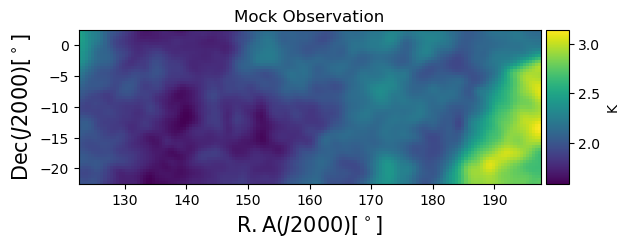

In [ ]:
label='K'
title='Mock Observation'
plot_patch(mock21[:,:,0],label,title,extent)

In [ ]:
freqs=np.load('data/final_mock21.npz')['freqs']

In [ ]:
freqs

array([850., 851., 852., 853., 854., 855., 856., 857., 858., 859., 860.,
       861., 862., 863., 864., 865., 866., 867., 868., 869., 870., 871.,
       872., 873., 874., 875., 876., 877., 878., 879., 880., 881., 882.,
       883., 884., 885., 886., 887., 888., 889., 890., 891., 892., 893.,
       894., 895., 896., 897., 898., 899., 900., 901., 902., 903., 904.,
       905., 906., 907., 908., 909., 910., 911., 912., 913., 914., 915.,
       916., 917., 918., 919., 920., 921., 922., 923., 924., 925., 926.,
       927., 928., 929., 930., 931., 932., 933., 934., 935., 936., 937.,
       938., 939., 940., 941., 942., 943., 944., 945., 946., 947., 948.,
       949.])

### We plot here what we would like to find

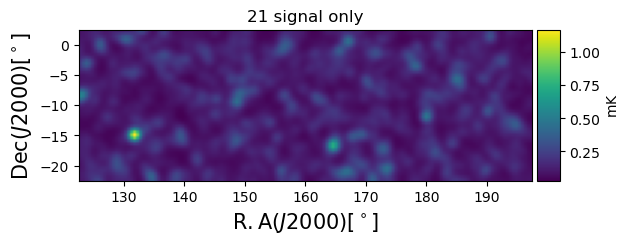

In [ ]:
signal=np.load('data/sig_only.npz')['signal']
plot_patch(signal[:,:,10]*1e3,r'${\rm mK}$','21 signal only',extent)

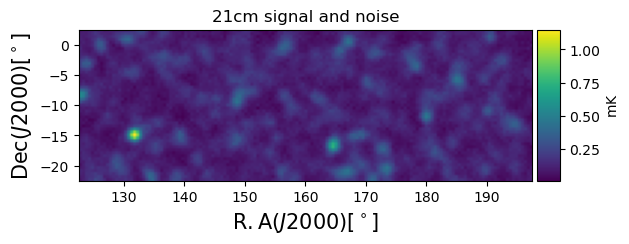

In [ ]:
sig_noise=np.load('data/sig_noise.npz')['sig_noise']
plot_patch(sig_noise[:,:,10]*1e3,r'${\rm mK}$','21cm signal and noise',extent)

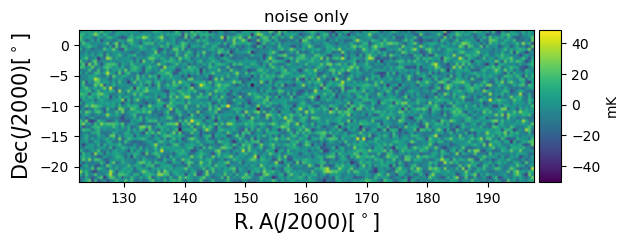

In [ ]:
noise=np.load('data/noise_only.npz')['noise']
plot_patch(noise[:,:,10]*1e3,r'${\rm mK}$','noise only',extent)

# Foreground cleaning

## Let's have a look at the math implementing PCA

Flat the map in an array

In [ ]:
# convert into array with NfreqxNpix
X=np.zeros((Nf,Nx*Ny))

for ff in range(Nf):
    X[ff,:]=mock21[:,:,ff].flatten()

print('X', X.shape)

X (100, 7701)


Compute the frequency-frequancy covariance matrix

In [ ]:
C=np.dot(X,X.T)
print('C',C.shape)

C (100, 100)


Evaluate eigen values and eigenvectors

In [ ]:
w, v = LA.eig(C)

How do the eigenvvalues behave? How many components should we subtract?

(1.0, 10.0)

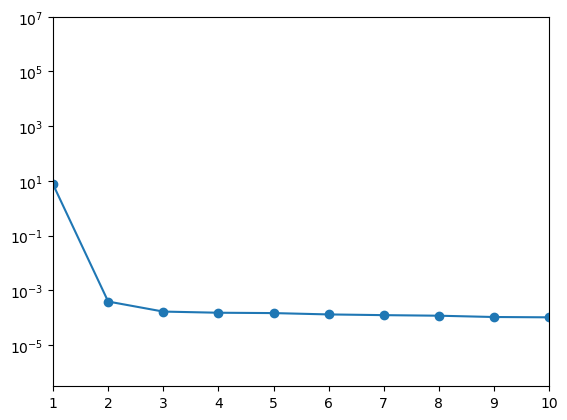

In [ ]:
plt.plot(np.arange(len(w)),w,marker='o')
plt.yscale('log')
plt.xlim(1,10)

We choose 3 (with current real data 3 is surely not enough!)

In [ ]:
NUM=3
Ah=v[:,0:NUM]
Ah.shape

(100, 3)

Ah ($\hat{\mathbf{A}}$) is the matrix composed by the first NUM eigenvector of $\mathbf{C}$

We now compute the projection of the selected eigenvectors along the data, obtaining the eigen-sources
$S=(\hat{\mathbf{A}}\mathbf{A}^{\rm T})^{-1}\mathbf{A}^{\rm T}\mathbf{X}$

In [ ]:
piA=np.dot(LA.inv(np.dot(Ah.T,Ah)),Ah.T)
S=np.dot(piA,X)
print(S.shape)

(3, 7701)


### Visualize the component maps

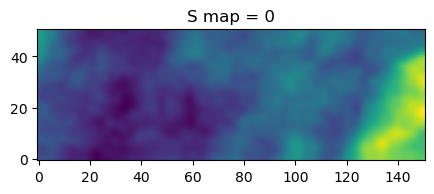

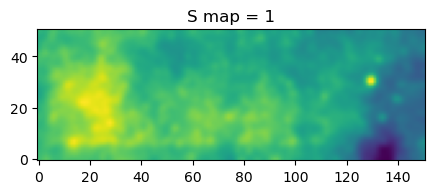

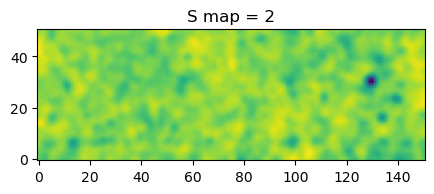

In [ ]:
Compmap=np.zeros((NUM, Nx,Ny))
for j in range(0, NUM):
    plt.figure(figsize=(5,5))
    Compmap[j]=S[j,:].reshape((Nx,Ny), order="A")
    plt.imshow(Compmap[j].T, cmap="viridis",origin='lower')
    plt.title("S map = "+str(j))

Do you recognise similarity with the input components?

### Compute the residuals: the reconstructed HI signal!

In [ ]:
res=X-np.dot(Ah,S)
res.shape

(100, 7701)

In [ ]:
#Convert back into cube of (Nx,Ny,Nf)
RecHI_PCA=np.zeros((Nx,Ny,Nf))
for ff in range(Nf):
    RecHI_PCA[:,:,ff]=res[ff,:].reshape((Nx,Ny))

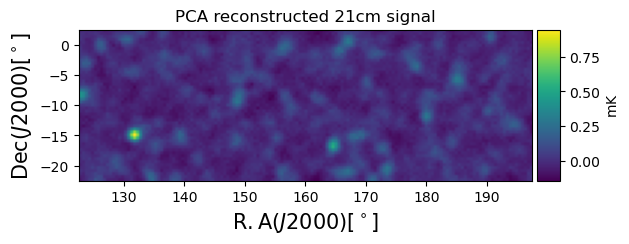

In [ ]:
plot_patch(RecHI_PCA[:,:,10]*1e3,r'${\rm mK}$','PCA reconstructed 21cm signal',extent)

### We now do a quick evaluation of the LOS power spectrum

In [ ]:
def pklos(patch):
    Nx,Ny,Nf=patch.shape
    kf=np.fft.fftfreq(Nf)
    Pk=np.zeros(Nf)
    for nx in range(Nx):
        for ny in range(Ny):
            Pk+=np.abs(np.fft.fftn(patch[nx,ny,:]))**2
    return kf, Pk/(Nx*Ny)

In [ ]:
kf, Pko= pklos(sig_noise)
kf, Pks= pklos(signal)
kf, PkPCA=pklos(RecHI_PCA)
#kf, PkFastICA=pklos(RecHI_FastICA)

Text(0.5, 1.0, 'NUM=3')

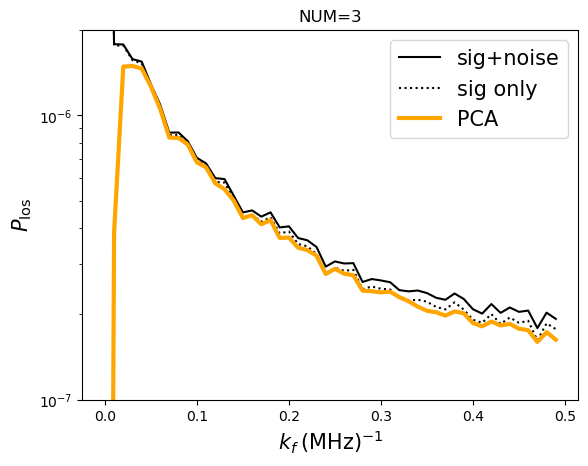

In [ ]:
plt.plot(kf[:int(Nf/2)],Pko[:int(Nf/2)],label='sig+noise',color='k')
plt.plot(kf[:int(Nf/2)],Pks[:int(Nf/2)],label='sig only',color='k',linestyle=':')
plt.plot(kf[:int(Nf/2)],PkPCA[:int(Nf/2)],label='PCA',color='orange',linewidth=3.)
#plt.plot(kf[:int(Nf/2)],PkFastICA[:int(Nf/2)],label='FastICA',color='m',linestyle='--')
plt.yscale('log')
plt.ylim(1e-7,2e-6)
plt.legend(fontsize=15)
plt.ylabel(r'$P_{\rm los}$',fontsize=15)
plt.xlabel(r'$k_f \: ({\rm MHz})^{-1}$',fontsize=15)
plt.title('NUM=3')